# Credit Risk Dataset — Group Preprocessing Pipeline
IT2011 Artificial Intelligence and Machine Learning — Progress Review I

**Group ID:** 2026-Y2-S1-MET-18

**Members:**
| Section | Technique | Name | IT Number |
|---|---|---|---|
| 1 | Duplicate Data Handling | Gunawardana  H.S.T | IT25102128 |
| 2 | Handling Missing Data| Bandara R.M.H.G | IT25102122 |
| 3 | Outlier Detection | Wijesinghe  W.M.S.N | IT25102124 |
| 4 | One-Hot Encoding| Ekanayaka  E.M.A.M | IT25102129 |
| 5 | Feature Selection / Feature Analysis |Seniri  G.H.M.D.M  | IT25102123 |
| 6 | Standardization / Scaling | Jayamanna N.G.K.D | IT25102121 |

## Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)

# Check files inside the downloaded folder
print("\nFiles in dataset folder:")
print(os.listdir(path))

# Load the dataset
file_path = os.path.join(path, "credit_risk_dataset.csv")

df = pd.read_csv(file_path)

print("\nDataset loaded successfully!")

# Display first 5 rows
print(df.head())

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Path to dataset files: /kaggle/input/credit-risk-dataset

Files in dataset folder:
['credit_risk_dataset.csv']

Dataset loaded successfully!
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDIC

## Understand and Inspect the Dataset


In [ ]:
# First 5 rows
print("First 5 rows:")
print(df.head())

# Last 5 rows
print("\nLast 5 rows:")
print(df.tail())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Include categorical columns in summary
print("\nComplete Summary:")
print(df.describe(include="all"))

First 5 rows:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                 

## Data Cleaning


In [ ]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDuplicates after removing:")
print(df.duplicated().sum())

# Check missing values again
print("\nMissing values:")
print(df.isnull().sum())

# Handle missing numerical values using median
if "person_emp_length" in df.columns:
    df["person_emp_length"] = df["person_emp_length"].fillna(
        df["person_emp_length"].median()
    )

if "loan_int_rate" in df.columns:
    df["loan_int_rate"] = df["loan_int_rate"].fillna(
        df["loan_int_rate"].median()
    )

# Final missing value check
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Check final dataset shape
print("\nDataset shape after cleaning:")
print(df.shape)

Missing values before cleaning:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Number of duplicate rows:
165

Duplicates after removing:
0

Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing values after cl

## Exploratory Data Analysis (EDA)



Loan Status Distribution:
loan_status
0    25327
1     7089
Name: count, dtype: int64

Loan Status Percentage:
loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64


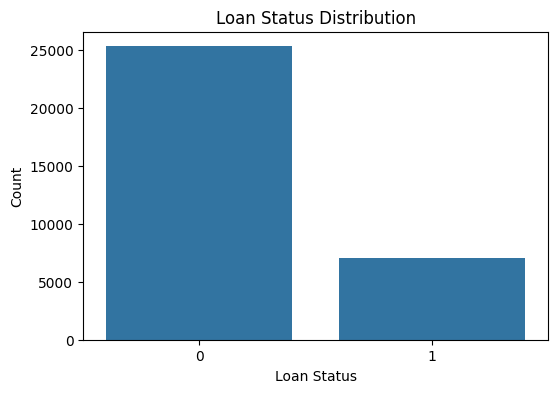

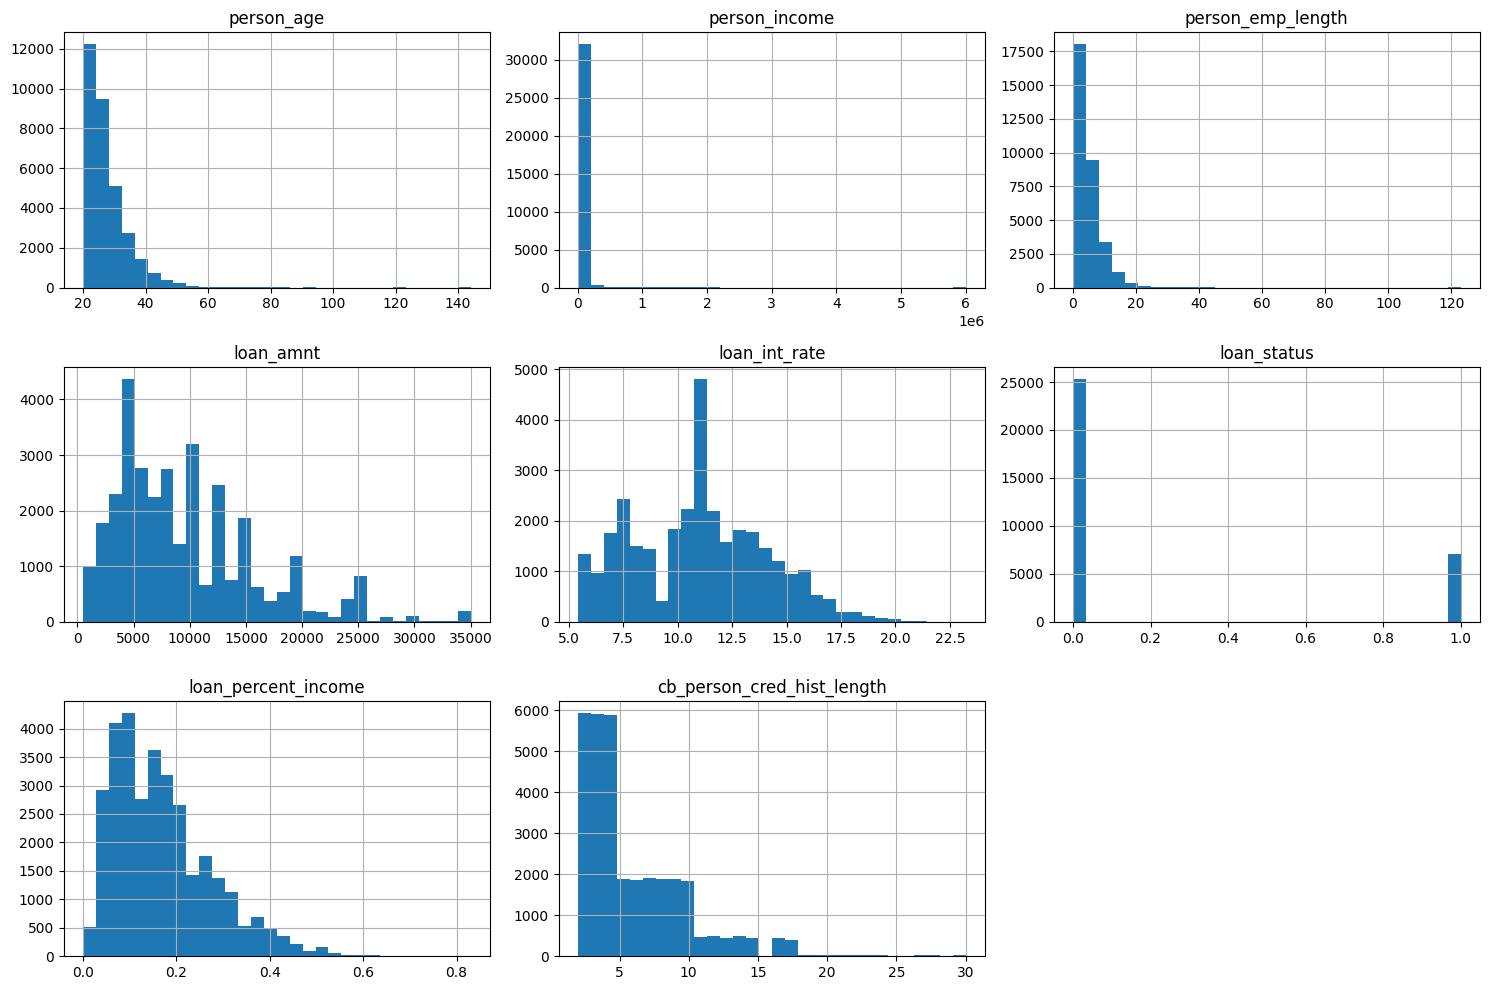

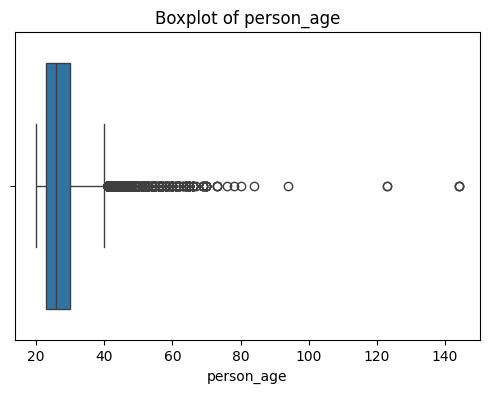

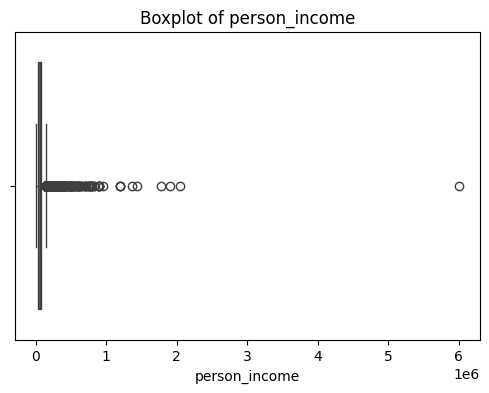

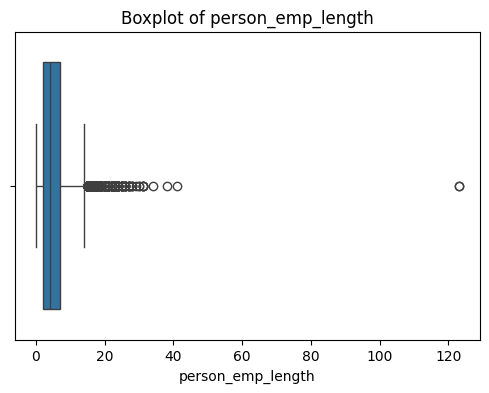

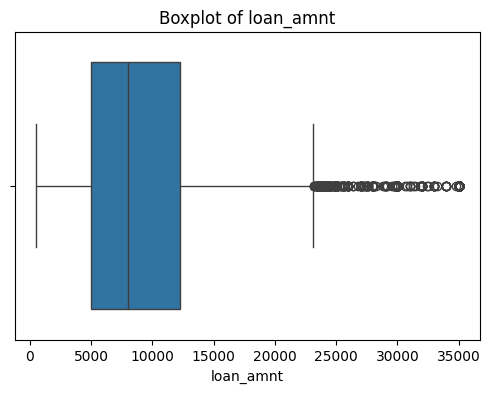

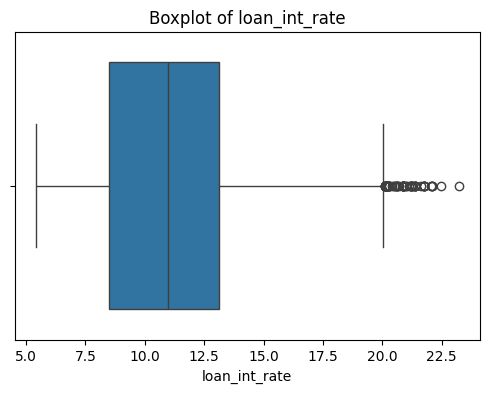

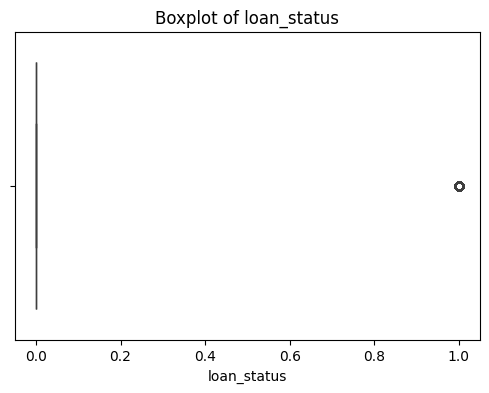

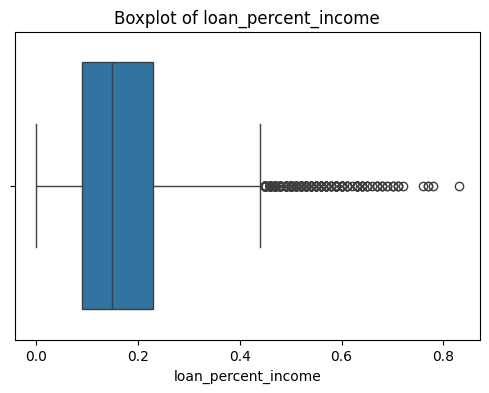

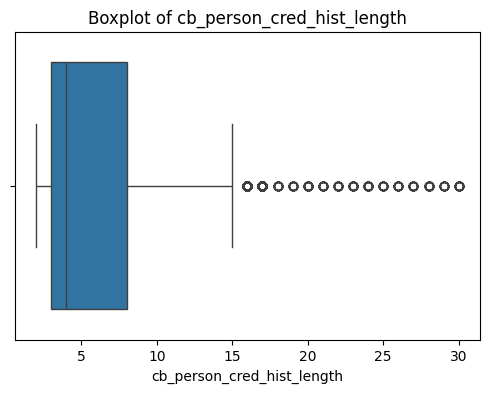


Categorical Columns:
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

Value Counts for person_home_ownership:
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

Value Counts for loan_intent:
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

Value Counts for loan_grade:
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

Value Counts for cb_person_default_on_file:
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64


In [ ]:
# Target variable distribution
print("Loan Status Distribution:")
print(df["loan_status"].value_counts())

print("\nLoan Status Percentage:")
print(df["loan_status"].value_counts(normalize=True) * 100)

# Target distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


# Histograms for numerical columns
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()


# Boxplots for numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()


# Categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("\nCategorical Columns:")
print(categorical_columns)

# Display value counts
for column in categorical_columns:
    print(f"\nValue Counts for {column}:")
    print(df[column].value_counts())

## Feature Analysis and Define X & y



Correlation Matrix:
                            person_age  person_income  person_emp_length  \
person_age                    1.000000       0.173293           0.161342   
person_income                 0.173293       1.000000           0.134791   
person_emp_length             0.161342       0.134791           1.000000   
loan_amnt                     0.050680       0.265947           0.113934   
loan_int_rate                 0.011074       0.000826          -0.051462   
loan_status                  -0.022698      -0.145005          -0.082517   
loan_percent_income          -0.042300      -0.254472          -0.054024   
cb_person_cred_hist_length    0.859215       0.117614           0.143251   

                            loan_amnt  loan_int_rate  loan_status  \
person_age                   0.050680       0.011074    -0.022698   
person_income                0.265947       0.000826    -0.145005   
person_emp_length            0.113934      -0.051462    -0.082517   
loan_amnt          

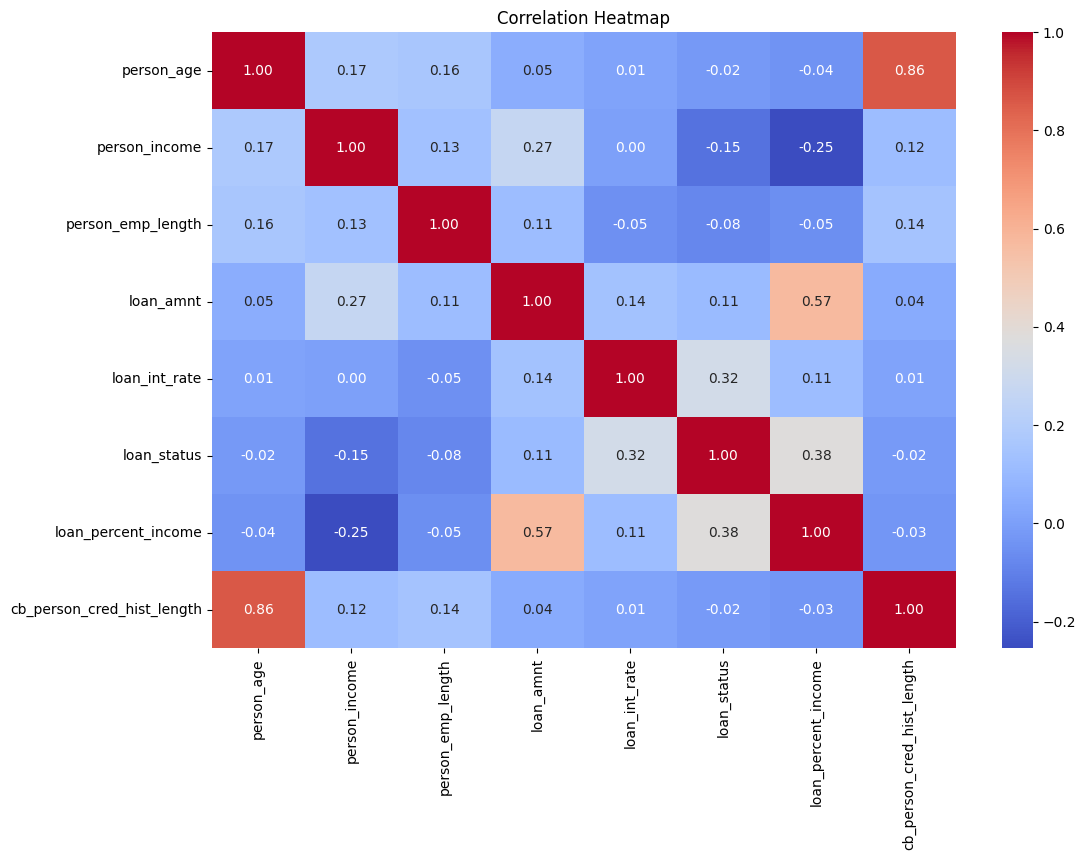


X Shape:
(32416, 11)

y Shape:
(32416,)

Input Features:
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

Target:
loan_status

Numerical Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [ ]:
# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation matrix
correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)


# Correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


# Define input features X
X = df.drop("loan_status", axis=1)

# Define target variable y
y = df["loan_status"]

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)

print("\nInput Features:")
print(X.columns)

print("\nTarget:")
print(y.name)


# Identify numerical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

## Train/Test Split, Encoding and Scaling


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# --------------------------------
# 1. Train-Test Split
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# --------------------------------
# 2. Identify columns
# --------------------------------

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


# --------------------------------
# 3. Numerical preprocessing
# --------------------------------

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# --------------------------------
# 4. Categorical preprocessing
# --------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# --------------------------------
# 5. Combine preprocessing
# --------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# --------------------------------
# 6. Transform training/test data
# --------------------------------

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)


# --------------------------------
# 7. Check final shapes
# --------------------------------

print("\nFinal Processed Data:")

print(
    "X_train_processed shape:",
    X_train_processed.shape
)

print(
    "X_test_processed shape:",
    X_test_processed.shape
)

print(
    "y_train shape:",
    y_train.shape
)

print(
    "y_test shape:",
    y_test.shape
     )

X_train shape: (25932, 11)
X_test shape: (6484, 11)
y_train shape: (25932,)
y_test shape: (6484,)

Numerical Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Final Processed Data:
X_train_processed shape: (25932, 26)
X_test_processed shape: (6484, 26)
y_train shape: (25932,)
y_test shape: (6484,)


---
## Technique 1: Duplicate Data Handling

**Section owner:
Gunawardana  H.S.T | IT25102128**

The code identifies and removes duplicate records from the Credit Risk dataset. This is needed to prevent repeated records from affecting the accuracy of the analysis and model results.

In [ ]:
# ==============================
# MEMBER 1
# Dataset Loading + Duplicate Handling
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)

# Check files inside the downloaded folder
print("\nFiles in dataset folder:")
print(os.listdir(path))

# Load the dataset
file_path = os.path.join(path, "credit_risk_dataset.csv")

df = pd.read_csv(file_path)

print("\nDataset loaded successfully!")

# Display first 5 rows
print(df.head())


# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDuplicates after removing:")
print(df.duplicated().sum())

# Check dataset shape after duplicate removal
print("\nDataset shape:")
print(df.shape)

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Path to dataset files: /kaggle/input/credit-risk-dataset

Files in dataset folder:
['credit_risk_dataset.csv']

Dataset loaded successfully!
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDIC

---
## Technique 2: Handling Missing Data

**Section owner:
Bandara R.M.H.G| IT25102122**

Same steps as Lab 2: check the shape, count duplicates, drop them, then check and drop nulls.

In [ ]:
# ==============================
# MEMBER 2
# Dataset Inspection + Missing Data Handling
# ==============================

# First 5 rows
print("First 5 rows:")
print(df.head())

# Last 5 rows
print("\nLast 5 rows:")
print(df.tail())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Include categorical columns in summary
print("\nComplete Summary:")
print(df.describe(include="all"))


# Check missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Handle missing numerical values using median
if "person_emp_length" in df.columns:
    df["person_emp_length"] = df["person_emp_length"].fillna(
        df["person_emp_length"].median()
    )

if "loan_int_rate" in df.columns:
    df["loan_int_rate"] = df["loan_int_rate"].fillna(
        df["loan_int_rate"].median()
    )

# Final missing value check
print("\nMissing values after cleaning:")
print(df.isnull().sum())

First 5 rows:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                 

---
## Technique 3: Outlier Detection
**Section owner:
Wijesinghe  W.M.S.N | IT25102124**

Same IQR method as Lab 2, Step 9. The method is currently used only to detect potential outliers; no rows are removed at this stage

Loan Status Distribution:
loan_status
0    25327
1     7089
Name: count, dtype: int64

Loan Status Percentage:
loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64


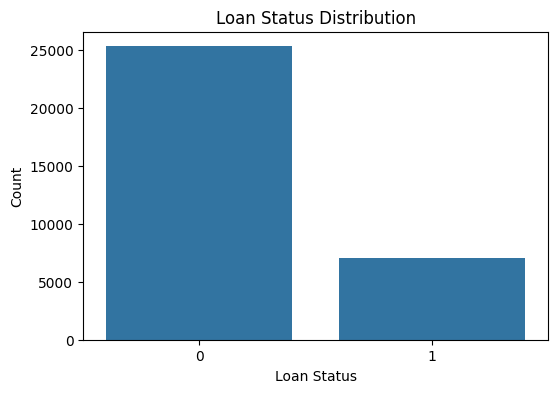

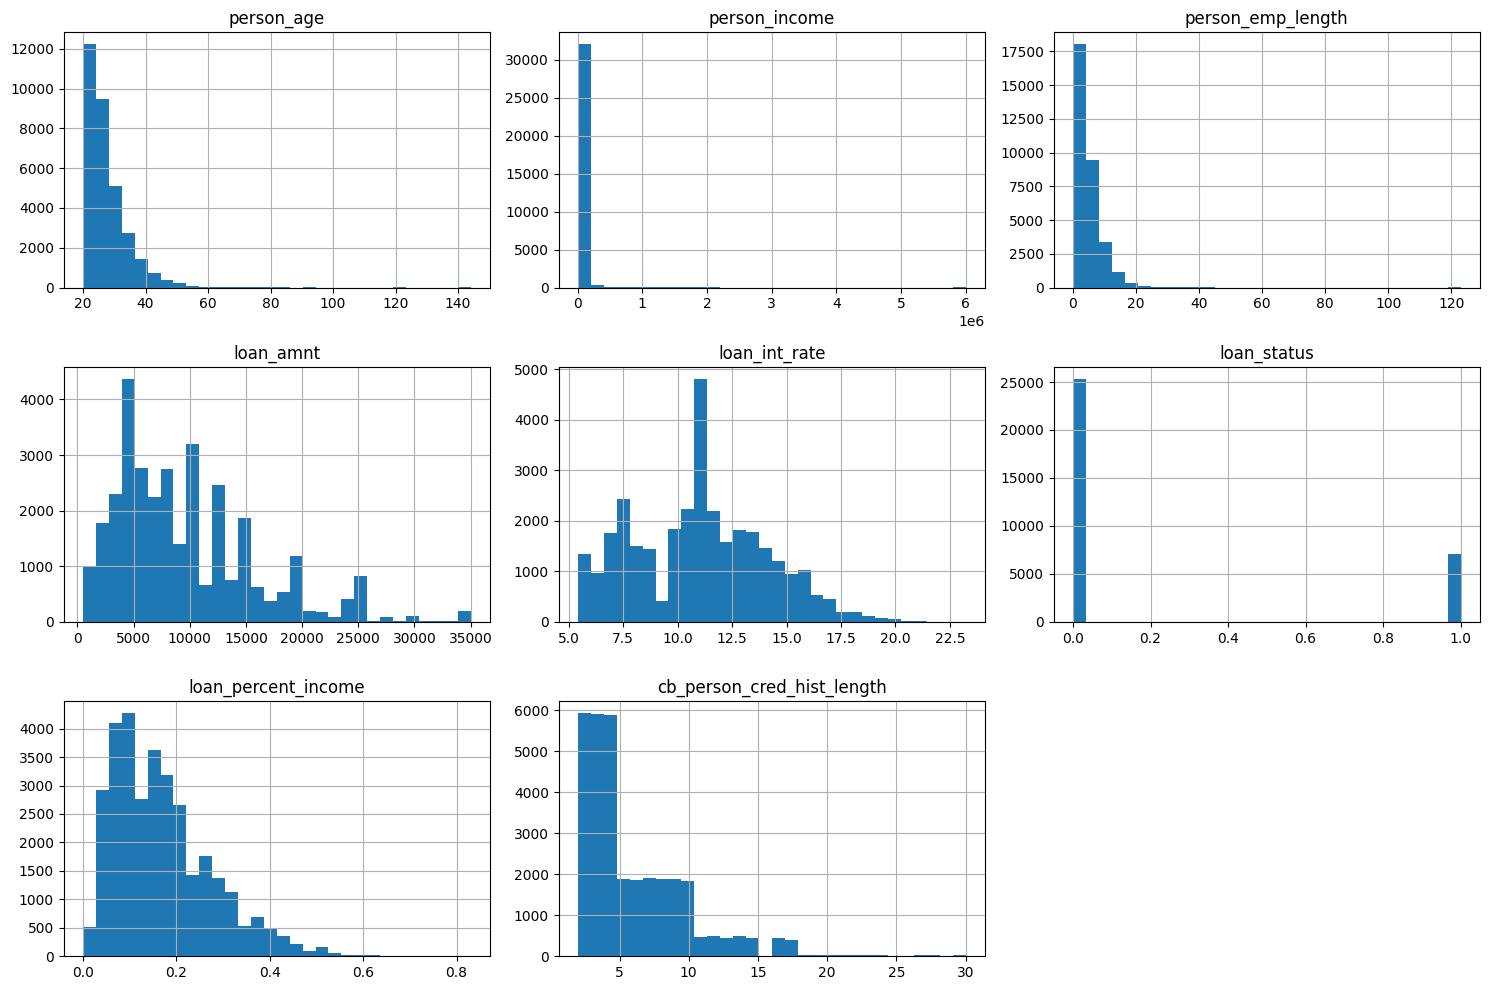

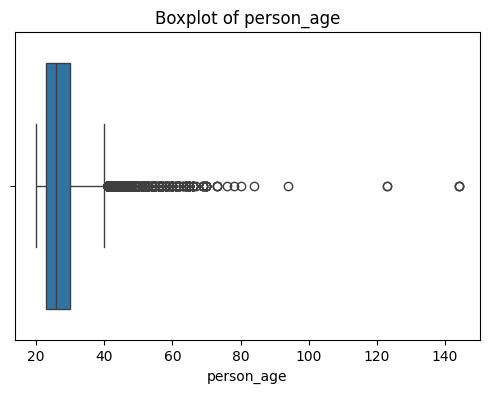

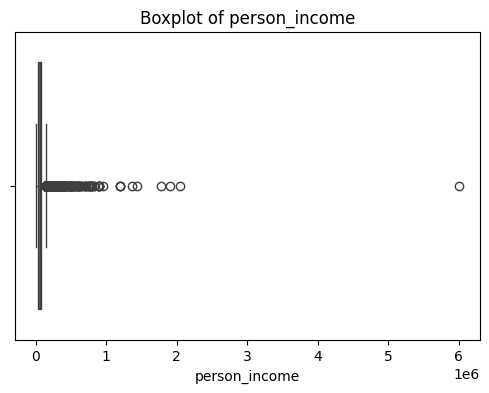

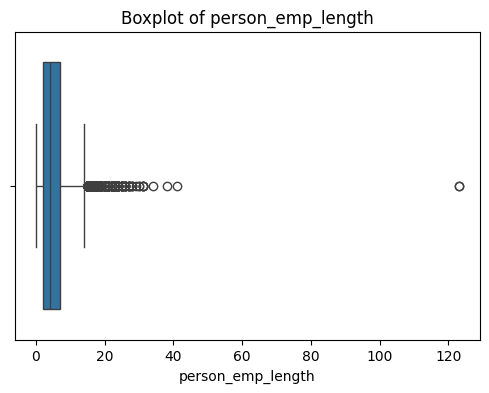

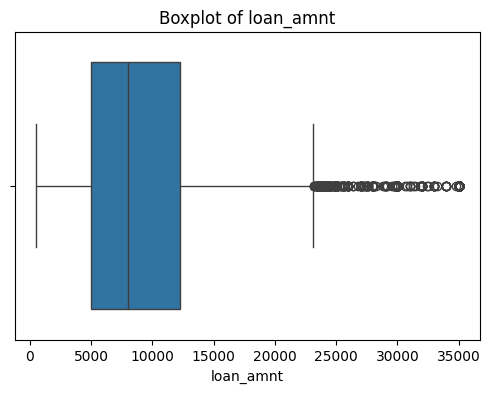

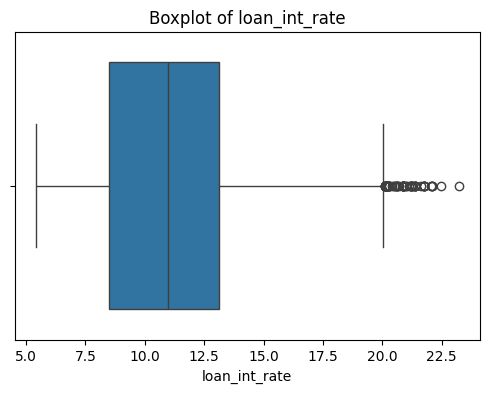

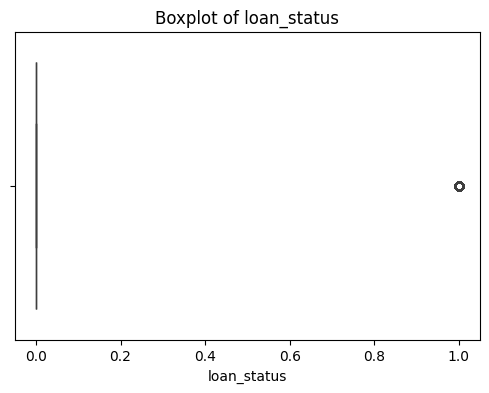

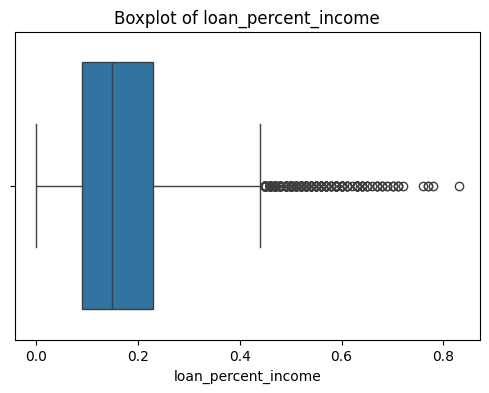

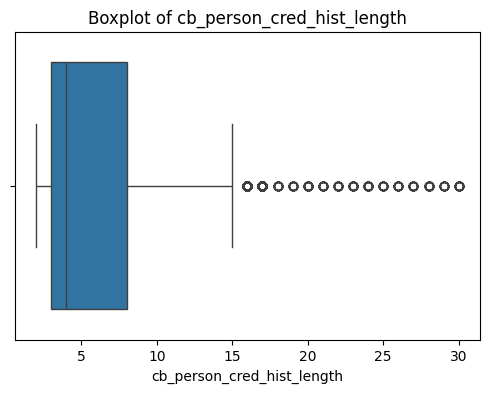


Categorical Columns:
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

Value Counts for person_home_ownership:
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

Value Counts for loan_intent:
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

Value Counts for loan_grade:
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

Value Counts for cb_person_default_on_file:
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64


In [ ]:
# ==============================
# MEMBER 3
# EDA + Outlier Detection
# ==============================

# Target variable distribution
print("Loan Status Distribution:")
print(df["loan_status"].value_counts())

print("\nLoan Status Percentage:")
print(df["loan_status"].value_counts(normalize=True) * 100)

# Target distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


# Histograms for numerical columns
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()


# Boxplots for numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()


# Categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("\nCategorical Columns:")
print(categorical_columns)

# Display value counts
for column in categorical_columns:
    print(f"\nValue Counts for {column}:")
    print(df[column].value_counts())

---
## Technique 4: Encoding Categorical Variables
**Section owner:
Ekanayaka  E.M.A.M| IT25102129**

The code converts categorical variables into numerical values using One-Hot Encoding. This is needed because machine-learning models require numerical input data.

In [ ]:
# ==============================
# MEMBER 4
# Encoding Categorical Variables
# ==============================

from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# Identify categorical features
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)


# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("\nCategorical preprocessing pipeline created successfully.")

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Categorical preprocessing pipeline created successfully.


---
## Technique 5: Feature Analysis / Selection
 **Section owner:
Seniri  G.H.M.D.M | IT25102123**

Same as Lab 3 Step 6 / Lab 4 — correlate every feature against the target and use the heatmap to decide what to drop, instead of feature-vs-feature.

Correlation Matrix:
                            person_age  person_income  person_emp_length  \
person_age                    1.000000       0.173293           0.161342   
person_income                 0.173293       1.000000           0.134791   
person_emp_length             0.161342       0.134791           1.000000   
loan_amnt                     0.050680       0.265947           0.113934   
loan_int_rate                 0.011074       0.000826          -0.051462   
loan_status                  -0.022698      -0.145005          -0.082517   
loan_percent_income          -0.042300      -0.254472          -0.054024   
cb_person_cred_hist_length    0.859215       0.117614           0.143251   

                            loan_amnt  loan_int_rate  loan_status  \
person_age                   0.050680       0.011074    -0.022698   
person_income                0.265947       0.000826    -0.145005   
person_emp_length            0.113934      -0.051462    -0.082517   
loan_amnt          

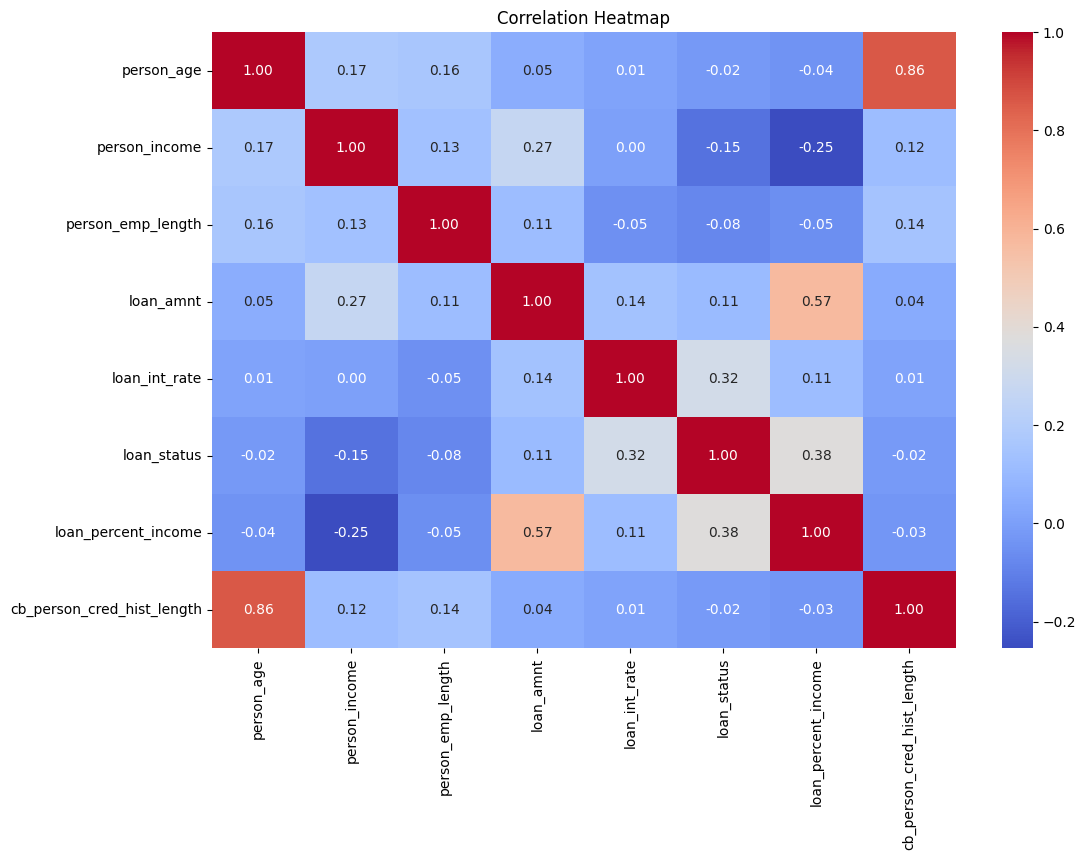


X Shape:
(32416, 11)

y Shape:
(32416,)

Input Features:
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

Target:
loan_status

Numerical Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [ ]:
# ==============================
# MEMBER 5
# Feature Analysis + X and y
# ==============================

# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation matrix
correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)


# Correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


# Define input features X
X = df.drop("loan_status", axis=1)

# Define target variable y
y = df["loan_status"]

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)

print("\nInput Features:")
print(X.columns)

print("\nTarget:")
print(y.name)


# Identify numerical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

---
## Technique 6: Normalization / Scaling
**Section owner:
Jayamanna N.G.K.D | IT25102121**

The code uses StandardScaler to standardize numerical features to a similar scale. This is needed to prevent features with larger values from dominating the model.

In [ ]:
# ==============================
# MEMBER 6
# Train/Test Split + Scaling + Final Preprocessing
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# --------------------------------
# 1. Train-Test Split
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# --------------------------------
# 2. Identify columns
# --------------------------------

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


# --------------------------------
# 3. Numerical preprocessing
# --------------------------------

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# --------------------------------
# 4. Categorical preprocessing
# --------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# --------------------------------
# 5. Combine preprocessing
# --------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# --------------------------------
# 6. Transform training/test data
# --------------------------------

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)


# --------------------------------
# 7. Check final shapes
# --------------------------------

print("\nFinal Processed Data:")

print(
    "X_train_processed shape:",
    X_train_processed.shape
)

print(
    "X_test_processed shape:",
    X_test_processed.shape
)

print(
    "y_train shape:",
    y_train.shape
)

print(
    "y_test shape:",
    y_test.shape
)

X_train shape: (25932, 11)
X_test shape: (6484, 11)
y_train shape: (25932,)
y_test shape: (6484,)

Numerical Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Final Processed Data:
X_train_processed shape: (25932, 26)
X_test_processed shape: (6484, 26)
y_train shape: (25932,)
y_test shape: (6484,)


---
## Final Preprocessed Dataset
**Integrated by the full group.**

In [ ]:
# Create a copy of the preprocessed features
final_df = X.copy()

# Add the target column back for the final dataset
final_df["loan_status"] = y.values

# Check final dataset shape
print("Final shape:", final_df.shape)

# Check target distribution
print("\nLoan Status Distribution:")
print(final_df["loan_status"].value_counts())


# Create a sample containing both target classes
sample_mix = pd.concat([
    final_df[final_df["loan_status"] == 0].sample(3, random_state=42),
    final_df[final_df["loan_status"] == 1].sample(3, random_state=42)
]).sort_index()

print("\nSample of Final Preprocessed Dataset:")
sample_mix



Final shape: (32416, 12)

Loan Status Distribution:
loan_status
0    25327
1     7089
Name: count, dtype: int64

Sample of Final Preprocessed Dataset:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
1428,21,26500,MORTGAGE,3.0,MEDICAL,D,6000,14.46,0.23,Y,4,1
16599,25,83004,MORTGAGE,9.0,DEBTCONSOLIDATION,A,5000,6.76,0.06,N,3,0
17896,28,288000,RENT,5.0,DEBTCONSOLIDATION,E,25000,17.93,0.09,N,8,1
18913,27,60000,RENT,11.0,DEBTCONSOLIDATION,B,1800,11.46,0.03,N,8,0
24146,30,42000,RENT,4.0,MEDICAL,C,10000,16.11,0.24,N,9,0
32092,40,45996,RENT,4.0,DEBTCONSOLIDATION,D,20000,14.61,0.43,Y,13,1


In [ ]:
# Save final preprocessed dataset
import os

os.makedirs("results/outputs", exist_ok=True)

final_df.to_csv(
    "results/outputs/final_processed_data.csv",
    index=False
)

print("\nFinal preprocessed dataset saved successfully!")


Final preprocessed dataset saved successfully!
